# Import Packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision

import matplotlib.pyplot as plt

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset

from pytorch_adapt.datasets import MNISTM

# Set device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"Using device: {device}")

Using device: cuda


# Dataloader

In [3]:
# for MNIST-M (already 3 channel)
transforms_mnist_m = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Train
mnist_m_train = ImageFolder(
    root="data/MNIST-M/training",
    transform=transforms_mnist_m
)

mnist_m_train_loader = DataLoader(
    mnist_m_train,
    batch_size=64,
    shuffle=True
)

# Test
mnist_m_test = ImageFolder(
    root="data/MNIST-M/testing",
    transform=transforms_mnist_m
)

mnist_m_test_loader = DataLoader(
    mnist_m_test,
    batch_size=8,
    shuffle=False
)

print("Train size:", len(mnist_m_train))
print("Test size:", len(mnist_m_test))

Train size: 59000
Test size: 9000


In [4]:
# for MNIST (1 channel --> 3 channel)
transforms_mnist = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Train split
mnist_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms_mnist
)

mnist_train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

# Test split
mnist_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms_mnist
)

mnist_test_loader = DataLoader(mnist_test, batch_size=8, shuffle=True)

print("Train size:", len(mnist_train))
print("Test size:", len(mnist_test))

Train size: 60000
Test size: 10000


In [5]:
def denormalize(tensor):
    return tensor * 0.5 + 0.5

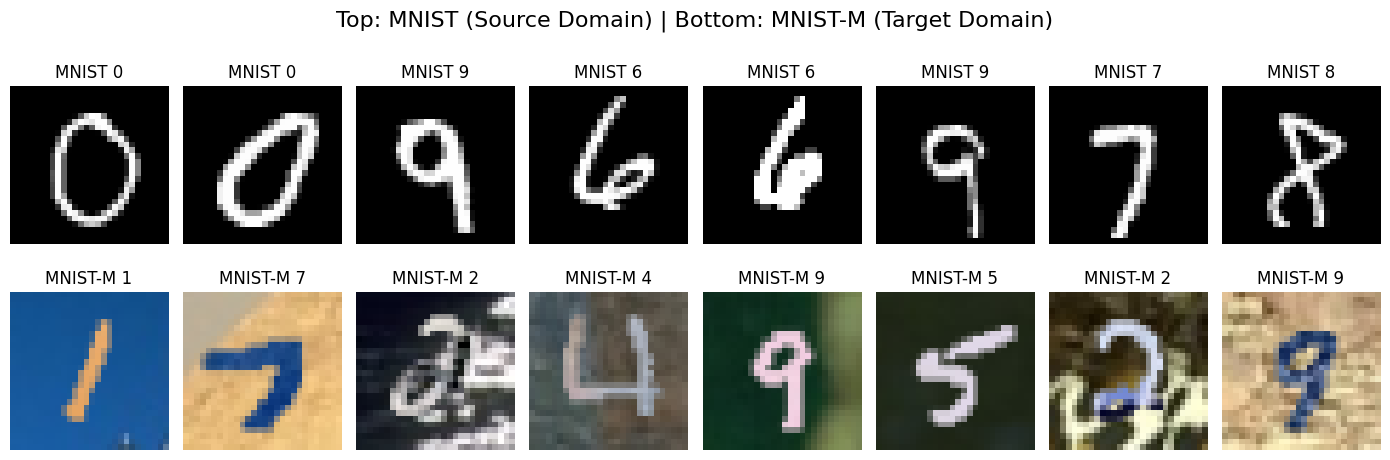

In [6]:
mnist_imgs, mnist_labels = next(iter(mnist_train_loader))
mnist_m_imgs, mnist_m_labels = next(iter(mnist_m_train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 5))

for i in range(8):
    axes[0, i].imshow(denormalize(mnist_imgs[i]).permute(1,2,0))
    axes[0, i].set_title(f"MNIST {mnist_labels[i].item()}")
    axes[0, i].axis("off")

    axes[1, i].imshow(denormalize(mnist_m_imgs[i]).permute(1,2,0))
    axes[1, i].set_title(f"MNIST-M {mnist_m_labels[i].item()}")
    axes[1, i].axis("off")

plt.suptitle("Top: MNIST (Source Domain) | Bottom: MNIST-M (Target Domain)", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
source_loader = mnist_train_loader
target_loader = mnist_m_train_loader

# Test loaders
source_test_loader = mnist_test_loader
target_test_loader = mnist_m_test_loader

# Models

## Feature Extractor

In [8]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 48, 5),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
    
    def forward(self, x):
        return self.conv(x).view(x.size(0), -1)

## Label Classifier

In [9]:
class LabelClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(48 * 4 * 4, 100),
            nn.ReLU(),
            nn.Linear(100, 10),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.fc(x)

## Domain Discriminator

In [10]:
class DomainDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(48 * 4 * 4, 100),
            nn.ReLU(),
            nn.Linear(100, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.fc(x)

## Gradient Reversal Layer

In [11]:
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def grad_reverse(x, alpha=1.0):
    return GradReverse.apply(x, alpha)

## Initialize Model

In [12]:
F = FeatureExtractor().to(device)
D = DomainDiscriminator().to(device)
C = LabelClassifier().to(device)

## LOSSESS AND OPTIMIZERS

In [13]:
criterion_class = nn.CrossEntropyLoss()
criterion_domain = nn.BCELoss()
optimizer_FC = optim.Adam(list(C.parameters()) + list(F.parameters()), lr=2e-4)
optimizer_D = optim.Adam(D.parameters(), lr=2e-4)

# TRAINING

In [16]:
from tqdm import tqdm

epochs = 50
for epoch in range(1, epochs + 1):
    F.train()
    C.train()
    D.train()
    
    tgt_iter = iter(target_loader)

    loop = tqdm(enumerate(source_loader), total=len(source_loader), desc=f"Epoch {epoch}/{epochs}")
    for i, (x_s, y_s) in loop:
        x_s, y_s = x_s.to(device), y_s.to(device)

        try:
            x_t, _ = next(tgt_iter)
        except StopIteration:
            tgt_iter = iter(target_loader)
            x_t, _ = next(tgt_iter)
        x_t = x_t.to(device)

        # forward
        x = torch.cat([x_s, x_t], dim=0)
        feat = F(x)

        # classification loss on source
        pred_class = C(feat[:x_s.size(0)])
        loss_class = criterion_class(pred_class, y_s)

        # domain loss on source and target
        feat_rev = grad_reverse(feat, alpha=1.0)
        domain_labels = torch.cat([
            torch.ones(x_s.size(0), 1, device=device, dtype=torch.float32),
            torch.zeros(x_t.size(0), 1, device=device, dtype=torch.float32)
        ], dim=0)
        pred_domain = D(feat_rev)
        loss_domain = criterion_domain(pred_domain, domain_labels)    

        # Update networks
        optimizer_FC.zero_grad()
        optimizer_D.zero_grad()
        loss = loss_class + loss_domain
        loss.backward()
        optimizer_FC.step()
        optimizer_D.step()

        # Update tqdm description
        if i % 5 == 0:
            loop.set_postfix(ClassLoss=loss_class.item(), DomainLoss=loss_domain.item())

Epoch 50/50: 100%|██████████| 938/938 [00:47<00:00, 19.84it/s, ClassLoss=1.51, DomainLoss=0.558]


# EVALUATE

In [17]:
def evaluate_on_target(F, C, test_loader):
    F.eval()
    C.eval()
    
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            feat = F(x)
            pred = C(feat)
            predicted = pred.argmax(dim=1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    acc = 100 * correct / total
    print(f'Target domain (MNIST-M) accuracy: {acc:.2f}%')
    return acc

In [19]:
evaluate_on_target(F, C, mnist_m_test_loader)

Target domain (MNIST-M) accuracy: 69.36%


69.35555555555555

# Training Loop Explanation (AI Generated)

## Gradient Reversal Layer (GRL) — Complete Explanation

## 1️⃣ Forward Pass

In DANN, the domain branch is written as:

```python
feat = F(x)
feat_rev = grad_reverse(feat)
pred_domain = D(feat_rev)
loss_domain = criterion(pred_domain, domain_labels)
```

### Forward Computation Graph

```
x
↓
F (Feature Extractor)
↓
feat
↓
GRL (acts as identity in forward)
↓
D (Domain Classifier)
↓
loss_domain
```

### Key Point

In the forward pass, GRL does **nothing**:

```python
def forward(ctx, x, alpha):
    ctx.alpha = alpha
    return x.view_as(x)
```

So:

```
feat_rev == feat
```

No values are changed during forward propagation.

---

## 2️⃣ Backward Pass (The Core Idea)

When we call:

```python
loss.backward()
```

The gradient flows backward like this:

```
loss_domain
    ↓
    D
    ↓
   GRL  ← gradient sign flipped here
    ↓
    F
```

Inside GRL’s backward function:

```python
def backward(ctx, grad_output):
    return -ctx.alpha * grad_output, None
```

Before the gradient reaches **F**, it is multiplied by `-alpha`.

This means:

- D receives **normal gradients**
- F receives **reversed gradients**

---

## 3️⃣ Total Loss

The overall loss is:

```
L = L_class + L_domain
```

And we minimize it using:

```python
loss.backward()
optimizer.step()
```

So globally, we are minimizing:

```
min (L_class + L_domain)
```

---

## 4️⃣ What Each Network Actually Minimizes

Because GRL reverses gradients flowing into F:

| Network | What It Minimizes |
|----------|------------------|
| C (Classifier) | L_class |
| D (Domain Classifier) | L_domain |
| F (Feature Extractor) | L_class - L_domain |

Why?

Because reversing the gradient is equivalent to performing **gradient ascent** on `L_domain` for F.

---

## 5️⃣ Why Reversing Gradient = Maximizing Loss

Normal gradient descent update:

```
param = param - lr * gradient
```

If gradient becomes negative:

```
gradient → -gradient
```

Then update becomes:

```
param = param - lr * (-gradient)
param = param + lr * gradient
```

That is **gradient ascent**.

So for F:

```
Minimize(-L_domain)  ≡  Maximize(L_domain)
```

This is the key idea.

---

## 6️⃣ The Min–Max Game

The training becomes an adversarial optimization:

```
min_{F,C} max_{D}  (L_class + L_domain)
```

Or equivalently from F’s perspective:

```
min_F (L_class - L_domain)
```

Meaning:

- D tries to correctly classify domains.
- F tries to confuse D.
- C tries to correctly classify source labels.

---

## 7️⃣ Intuition

- D learns to distinguish source vs target features.
- F learns to fool D by making features domain-invariant.
- C ensures features remain discriminative for classification.

Because of a single minus sign in the backward pass, we convert a simple loss into an adversarial min–max optimization.

---

## 8️⃣ Final Takeaway

The GRL:

- Does nothing in forward pass.
- Flips gradient sign in backward pass.
- Causes F to maximize domain loss.
- Keeps D minimizing domain loss.
- Creates adversarial domain adaptation behavior.

All of this happens because of:

```python
return -ctx.alpha * grad_output
```

## DANN Gradient Flow with GRL — Full Explanation

## Gradient Flow Diagram

```
           ┌─────────┐
x ---> F ---| feat    |----> C --- loss_class
           └─────────┘
                │
                ▼
             GRL(-1)
                │
                ▼
                D --- loss_domain
```

---

## 1️⃣ Classifier Branch (`C`)

- `loss_class` depends **only on source features** (`feat[:x_s.size(0)]`).  
- Gradient flows **upstream through C into F**.  
- Updates **C parameters** and **F parameters**.  
- **D does not see this loss** because it is not connected to C’s branch.  

**Summary:**

```
C ← loss_class
F ← loss_class (source features)
D ← not affected
```

---

## 2️⃣ Domain Branch (`D`)

- `loss_domain` depends on **both source and target features** (`feat_rev`).  
- Gradient flows **upstream through D into GRL and then F**.  
- GRL multiplies the gradient by **-1** before it reaches F.  
- Updates:

```
D ← loss_domain (normal gradient)
F ← -loss_domain (gradient reversed by GRL)
C ← not affected
```

---

## 3️⃣ Feature Extractor (`F`) Summary

F receives **gradients from both branches**:

1. **From C branch:** `+ loss_class` → minimize classification error.  
2. **From D branch via GRL:** `- loss_domain` → maximize domain loss (adversarial).  

Effective gradient for F:

```
grad_F = grad(loss_class) + (-grad(loss_domain))
```

This is why F learns **domain-invariant features** while still preserving classification performance on source data.

---

## 4️⃣ Key Insights

- GRL flips **only the gradient going into F**, not D.  
- C updates **only from classification loss**.  
- D updates **only from domain loss**.  
- F updates **from both losses**, using the reversed domain gradient for adversarial adaptation.  

This mechanism enables **unsupervised domain adaptation** by making feature representations invariant to domain while still discriminative for classification.